# SCFont：Structure-Guided Chinese Font Generation

这份 notebook 对 AAAI-19 的 SCFont 做一个可运行的小规模复现。论文把中文字体生成拆成两步：SkelNet 预测参考字体到目标字体的 skeleton flow，StyleNet 再把骨架渲染成目标字形。

原论文使用 70 种字体、GB2312 字符和人工校正的笔画轨迹；这里使用 000-dataset/fonts 中的字体，用 skimage.skeletonize 近似笔画骨架，并用最近骨架点构造可监督 flow。该实现复现论文的模型分工和损失设计，不声称重建原作者的私有笔画标注。

In [1]:
from pathlib import Path
import random, sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from scipy import ndimage
from skimage.morphology import skeletonize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 2026
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('python:', sys.executable)
print('torch:', torch.__version__, '| device:', DEVICE)

python: C:\Users\22936\.conda\envs\zi-font\python.exe
torch: 2.9.0+cpu | device: cpu


In [2]:
def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / '000-dataset').is_dir() and (p / '002-scfont-structure-guided-font-generation').is_dir():
            return p
    raise FileNotFoundError('请从 zi-font 项目目录启动 Jupyter。')

ROOT = find_root()
DATA_ROOT = ROOT / '000-dataset'
FONT_ROOT = DATA_ROOT / 'fonts'
OUT = ROOT / '002-scfont-structure-guided-font-generation' / 'outputs'
PREVIEW = OUT / 'data-preview'
CKPT = OUT / 'checkpoints'
for p in (OUT, PREVIEW, CKPT): p.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE, FONT_SIZE = 64, 52
BATCH_SIZE, FLOW_EPOCHS, STYLE_EPOCHS = 8, 3, 3
LR = 1e-3
FONT_PATHS = {p.stem: p for p in sorted(FONT_ROOT.glob('*.ttf'))}
REFERENCE_FONT = 'lxgw-wenkai' if 'lxgw-wenkai' in FONT_PATHS else next(iter(FONT_PATHS))
TARGET_FONT = 'longcang' if 'longcang' in FONT_PATHS else list(FONT_PATHS)[1]
CHARACTERS = list(dict.fromkeys('床前明月光疑是地上霜举头望明月低头思故乡山水人文化中天高云淡风清竹影梅花春秋'))
print('root:', ROOT)
print('reference:', REFERENCE_FONT, '| target:', TARGET_FONT, '| chars:', len(CHARACTERS))

root: D:\Desktop\zi-font
reference: lxgw-wenkai | target: longcang | chars: 35


## 1. 数据预处理：字体、骨架和近似 stroke prior

In [3]:
def render_glyph(char, font_path, size=IMAGE_SIZE, font_size=FONT_SIZE):
    image = Image.new('L', (size, size), 255)
    ImageDraw.Draw(image).text((size / 2, size / 2), char, font=ImageFont.truetype(str(font_path), font_size), fill=0, anchor='mm')
    return np.asarray(image, dtype=np.uint8)

def ink(gray): return (gray < 245).astype(np.float32)
def skel(gray): return skeletonize(ink(gray) > 0).astype(np.float32)

def category_prior(skeleton, classes=8):
    gy, gx = np.gradient(skeleton.astype(np.float32))
    angle = (np.arctan2(gy, gx) + np.pi) % np.pi
    bins = np.clip(np.floor(angle / np.pi * classes).astype(np.int64), 0, classes - 1)
    return np.stack([(bins == i).astype(np.float32) * skeleton for i in range(classes)])

def nearest_flow(source, target):
    flow = np.zeros((*source.shape, 2), dtype=np.float32)
    if not source.any() or not target.any(): return flow
    _, indices = ndimage.distance_transform_edt(target <= 0, return_indices=True)
    for y, x in np.argwhere(source > 0):
        ty, tx = indices[0, y, x], indices[1, y, x]
        flow[y, x] = ((tx - x) / IMAGE_SIZE, (ty - y) / IMAGE_SIZE)
    return flow

class FontPairDataset(Dataset):
    def __init__(self, chars, reference, target): self.chars, self.reference, self.target = list(chars), reference, target
    def __len__(self): return len(self.chars)
    def __getitem__(self, i):
        char = self.chars[i]
        r = render_glyph(char, FONT_PATHS[self.reference]); t = render_glyph(char, FONT_PATHS[self.target])
        rs, ts = skel(r), skel(t)
        return {
            'char': char, 'reference': torch.from_numpy(ink(r)[None]),
            'reference_skeleton': torch.from_numpy(rs[None]), 'target': torch.from_numpy(ink(t)[None]),
            'target_skeleton': torch.from_numpy(ts[None]), 'prior': torch.from_numpy(category_prior(rs)),
            'flow': torch.from_numpy(nearest_flow(rs, ts).transpose(2, 0, 1))}

dataset = FontPairDataset(CHARACTERS, REFERENCE_FONT, TARGET_FONT)
sample = dataset[0]
print({k: (v.shape if hasattr(v, 'shape') else v) for k, v in sample.items()})

{'char': '床', 'reference': torch.Size([1, 64, 64]), 'reference_skeleton': torch.Size([1, 64, 64]), 'target': torch.Size([1, 64, 64]), 'target_skeleton': torch.Size([1, 64, 64]), 'prior': torch.Size([8, 64, 64]), 'flow': torch.Size([2, 64, 64])}


C:\Users\22936\AppData\Local\Temp\ipykernel_37828\1061046572.py:8: UserWarning: Glyph 24202 (\N{CJK UNIFIED IDEOGRAPH-5E8A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); return fig
C:\Users\22936\AppData\Local\Temp\ipykernel_37828\1061046572.py:11: UserWarning: Glyph 24202 (\N{CJK UNIFIED IDEOGRAPH-5E8A}) missing from font(s) DejaVu Sans.
  fig.savefig(PREVIEW / 'dataset-sample.png', dpi=160, bbox_inches='tight')
C:\Users\22936\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24202 (\N{CJK UNIFIED IDEOGRAPH-5E8A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


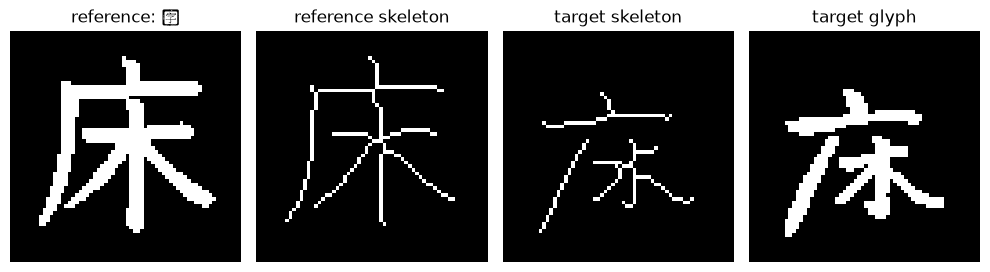

In [4]:
def plot_data_sample(i=0):
    item = dataset[i]
    images = [item['reference'][0], item['reference_skeleton'][0], item['target_skeleton'][0], item['target'][0]]
    titles = [f"reference: {item['char']}", 'reference skeleton', 'target skeleton', 'target glyph']
    fig, axes = plt.subplots(1, 4, figsize=(10, 3))
    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image, cmap='gray', vmin=0, vmax=1); ax.set_title(title); ax.axis('off')
    plt.tight_layout(); return fig

fig = plot_data_sample()
fig.savefig(PREVIEW / 'dataset-sample.png', dpi=160, bbox_inches='tight')
plt.show()

## 2. SkelNet：粗到细 skeleton flow prediction

论文使用 FlowNet 风格的 contracting/expanding 网络、stroke category prior 和 stacked refinement。这里实现一个两级 U-Net；flow endpoint loss 与 warp 后 skeleton 的结构损失共同训练。

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, a, b):
        super().__init__(); self.net = nn.Sequential(nn.Conv2d(a, b, 3, padding=1), nn.InstanceNorm2d(b), nn.LeakyReLU(.2, True), nn.Conv2d(b, b, 3, padding=1), nn.InstanceNorm2d(b), nn.LeakyReLU(.2, True))
    def forward(self, x): return self.net(x)

class SmallUNet(nn.Module):
    def __init__(self, cin, cout):
        super().__init__(); self.e1=ConvBlock(cin,32); self.e2=ConvBlock(32,64); self.e3=ConvBlock(64,96); self.pool=nn.AvgPool2d(2); self.d2=ConvBlock(160,64); self.d1=ConvBlock(96,32); self.head=nn.Conv2d(32,cout,3,padding=1)
    def forward(self, x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); d2=self.d2(torch.cat([F.interpolate(e3,size=e2.shape[-2:],mode='bilinear',align_corners=False),e2],1)); d1=self.d1(torch.cat([F.interpolate(d2,size=e1.shape[-2:],mode='bilinear',align_corners=False),e1],1)); return torch.tanh(self.head(d1))*.5

class SkelNet(nn.Module):
    def __init__(self):
        super().__init__(); self.stage1=SmallUNet(9,2); self.stage2=SmallUNet(11,2)
    def forward(self, x):
        f1=self.stage1(x); f2=self.stage2(torch.cat([x,f1],1)); return f1, f1+f2

def warp_batch(image, flow):
    n,_,h,w=image.shape; yy,xx=torch.meshgrid(torch.linspace(-1,1,h,device=image.device),torch.linspace(-1,1,w,device=image.device),indexing='ij'); base=torch.stack([xx,yy],-1).unsqueeze(0).repeat(n,1,1,1); return F.grid_sample(image, base+flow.permute(0,2,3,1)*2, mode='bilinear', padding_mode='zeros', align_corners=True)

def flow_loss(pred, truth, source, target):
    endpoint=(torch.abs(pred-truth)*(source.expand_as(pred)+.05)).mean(); structure=F.l1_loss(warp_batch(source,pred),target); return endpoint+.2*structure, endpoint.detach(), structure.detach()

flow_model=SkelNet().to(DEVICE)
print('SkelNet parameters:', sum(p.numel() for p in flow_model.parameters()))

SkelNet parameters: 745348


In [6]:
def device_batch(batch): return {k: v.to(DEVICE) if torch.is_tensor(v) else v for k,v in batch.items()}

def train_skelnet(model, data, epochs=FLOW_EPOCHS):
    loader=DataLoader(data,batch_size=BATCH_SIZE,shuffle=True,num_workers=0); opt=torch.optim.Adam(model.parameters(),lr=LR); history=[]; model.train()
    for epoch in range(epochs):
        total=np.zeros(3)
        for batch in loader:
            batch=device_batch(batch); x=torch.cat([batch['reference_skeleton'],batch['prior']],1); f1,f2=model(x); l1,_,_=flow_loss(f1,batch['flow'],batch['reference_skeleton'],batch['target_skeleton']); l2,epe,struct=flow_loss(f2,batch['flow'],batch['reference_skeleton'],batch['target_skeleton']); loss=.5*l1+l2; opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); total += np.array([loss.item(),epe.item(),struct.item()])*len(batch['reference'])
        record=total/len(data); history.append(record); print(f'flow epoch {epoch+1:02d}/{epochs}: loss={record[0]:.4f}, epe={record[1]:.4f}, structure={record[2]:.4f}')
    torch.save(model.state_dict(), CKPT/'skelnet-mini.pt'); return np.asarray(history)

flow_history=train_skelnet(flow_model,dataset)

flow epoch 01/3: loss=0.0471, epe=0.0228, structure=0.0545


flow epoch 02/3: loss=0.0363, epe=0.0140, structure=0.0495


flow epoch 03/3: loss=0.0345, epe=0.0139, structure=0.0445


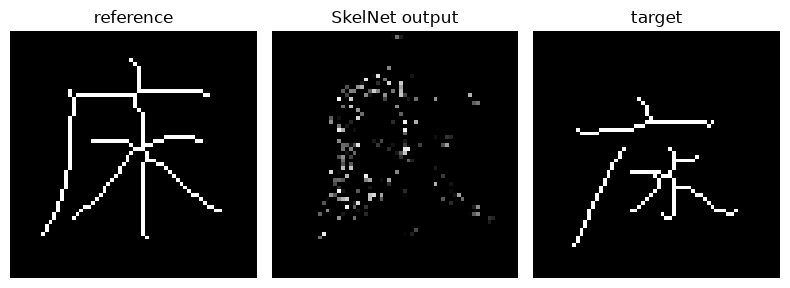

In [7]:
@torch.no_grad()
def predict_skeleton(model,item):
    model.eval(); b={k:v.unsqueeze(0).to(DEVICE) for k,v in item.items() if torch.is_tensor(v)}; _,flow=model(torch.cat([b['reference_skeleton'],b['prior']],1)); return warp_batch(b['reference_skeleton'],flow)[0,0].cpu().numpy()

pred=predict_skeleton(flow_model,dataset[0]); target=dataset[0]['target_skeleton'][0].numpy()
fig,axes=plt.subplots(1,3,figsize=(8,3))
for ax,img,title in zip(axes,[dataset[0]['reference_skeleton'][0],pred,target],['reference','SkelNet output','target']): ax.imshow(img,cmap='gray',vmin=0,vmax=1); ax.set_title(title); ax.axis('off')
plt.tight_layout(); fig.savefig(PREVIEW/'skelnet-output.png',dpi=160,bbox_inches='tight'); plt.show()

## 3. StyleNet：两阶段骨架渲染与 PatchGAN

StyleNet 对应论文中的 Stage-I / Stage-II generator 和 conditional PatchGAN。损失包含 adversarial、pixel 和 consistency 三部分；这里使用 100、15、1 的论文权重。

In [8]:
class StyleGenerator(nn.Module):
    def __init__(self):
        super().__init__(); self.e1=ConvBlock(1,32); self.e2=ConvBlock(32,64); self.e3=ConvBlock(64,96); self.pool=nn.AvgPool2d(2); self.res=nn.Sequential(ConvBlock(96,96),ConvBlock(96,96)); self.d2=ConvBlock(160,64); self.d1=ConvBlock(96,32); self.head=nn.Conv2d(32,1,3,padding=1)
    def encode(self,x): e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); return e1,e2,e3
    def forward(self,x):
        e1,e2,e3=self.encode(x); z=self.res(e3); d2=self.d2(torch.cat([F.interpolate(z,size=e2.shape[-2:],mode='bilinear',align_corners=False),e2],1)); d1=self.d1(torch.cat([F.interpolate(d2,size=e1.shape[-2:],mode='bilinear',align_corners=False),e1],1)); return torch.sigmoid(self.head(d1))

class PatchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__(); self.net=nn.Sequential(nn.Conv2d(2,32,4,2,1),nn.LeakyReLU(.2,True),nn.Conv2d(32,64,4,2,1),nn.InstanceNorm2d(64),nn.LeakyReLU(.2,True),nn.Conv2d(64,96,4,2,1),nn.InstanceNorm2d(96),nn.LeakyReLU(.2,True),nn.Conv2d(96,1,3,padding=1))
    def forward(self,skeleton,glyph): return self.net(torch.cat([skeleton,glyph],1))

class StyleNet(nn.Module):
    def __init__(self): super().__init__(); self.stage1=StyleGenerator(); self.stage2=StyleGenerator()
    def forward(self,x):
        y1=self.stage1(x); return y1,self.stage2(y1)

style_model=StyleNet().to(DEVICE); discriminator=PatchDiscriminator().to(DEVICE)
print('StyleNet parameters:',sum(p.numel() for p in style_model.parameters()))

StyleNet parameters: 1403906


In [9]:
def train_stylenet(generator,disc,data,epochs=STYLE_EPOCHS):
    loader=DataLoader(data,batch_size=BATCH_SIZE,shuffle=True,num_workers=0); go=torch.optim.Adam(generator.parameters(),lr=LR,betas=(.5,.999)); do=torch.optim.Adam(disc.parameters(),lr=LR,betas=(.5,.999)); bce=nn.BCEWithLogitsLoss(); history=[]
    for epoch in range(epochs):
        total=np.zeros(4)
        for batch in loader:
            batch=device_batch(batch); x=batch['target_skeleton']; real=batch['target']; y1,y2=generator(x); real_log=disc(x,real); fake_log=disc(x,y2.detach()); dl=.5*(bce(real_log,torch.ones_like(real_log))+bce(fake_log,torch.zeros_like(fake_log))); do.zero_grad(set_to_none=True); dl.backward(); do.step()
            y1,y2=generator(x); adv=bce(disc(x,y2),torch.ones_like(real_log)); pixel=F.l1_loss(y1,real)+F.l1_loss(y2,real); real_feat=generator.stage1.encode(real)[-1].detach(); fake_feat=generator.stage1.encode(y2)[-1]; consistency=F.l1_loss(fake_feat,real_feat); gl=adv+100*pixel+15*consistency; go.zero_grad(set_to_none=True); gl.backward(); go.step(); total += np.array([gl.item(),adv.item(),pixel.item(),consistency.item()])*len(real)
        record=total/len(data); history.append(record); print(f'style epoch {epoch+1:02d}/{epochs}: total={record[0]:.4f}, adv={record[1]:.4f}, pixel={record[2]:.4f}, consistency={record[3]:.4f}')
    torch.save(generator.state_dict(),CKPT/'stylenet-mini.pt'); torch.save(disc.state_dict(),CKPT/'patch-discriminator-mini.pt'); return np.asarray(history)

style_history=train_stylenet(style_model,discriminator,dataset)

style epoch 01/3: total=84.8816, adv=0.9023, pixel=0.7846, consistency=0.3682


style epoch 02/3: total=52.7600, adv=1.1596, pixel=0.5004, consistency=0.1038


style epoch 03/3: total=40.9263, adv=1.5051, pixel=0.3816, consistency=0.0840


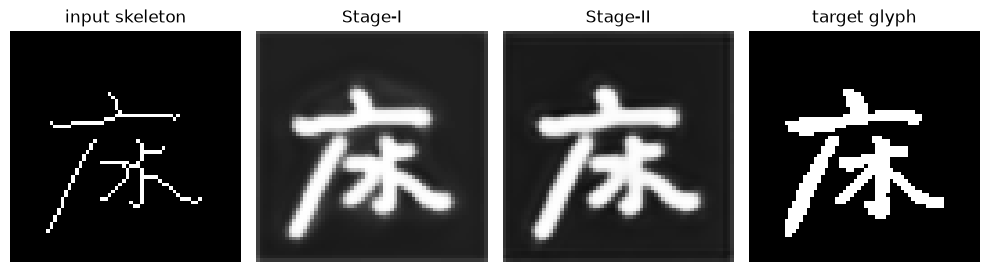

metrics: {'l1': 0.048583984375, 'iou': 0.7216783216783217}
outputs: D:\Desktop\zi-font\002-scfont-structure-guided-font-generation\outputs


In [10]:
@torch.no_grad()
def render_style(model,item):
    model.eval(); x=item['target_skeleton'].unsqueeze(0).to(DEVICE); y1,y2=model(x); return y1[0,0].cpu().numpy(),y2[0,0].cpu().numpy()

y1,y2=render_style(style_model,dataset[0]); real=dataset[0]['target'][0].numpy()
fig,axes=plt.subplots(1,4,figsize=(10,3))
for ax,img,title in zip(axes,[dataset[0]['target_skeleton'][0],y1,y2,real],['input skeleton','Stage-I','Stage-II','target glyph']): ax.imshow(img,cmap='gray',vmin=0,vmax=1); ax.set_title(title); ax.axis('off')
plt.tight_layout(); fig.savefig(PREVIEW/'stylenet-output.png',dpi=160,bbox_inches='tight'); plt.show()

def metrics(pred,target,threshold=.5):
    pred,target=np.asarray(pred)>threshold,np.asarray(target)>threshold; union=np.logical_or(pred,target).sum(); return {'l1':float(np.abs(pred.astype(float)-target.astype(float)).mean()),'iou':float(np.logical_and(pred,target).sum()/max(union,1))}
print('metrics:',metrics(y2,real)); print('outputs:',OUT)

## 4. 与论文实验的对应关系

| 论文 SCFont | 本 notebook |
|---|---|
| 70 种字体、GB2312、775/6000 字符 | 000-dataset/fonts、可配置小字符集 |
| 自动笔画抽取和 33 类 stroke prior | skeletonize 和 8 类方向 prior 近似 |
| stacked FlowNet 风格 SkelNet | 两级 U-Net flow refinement |
| 两阶段 StyleNet + conditional PatchGAN | 两个 U-Net generator + PatchGAN |
| EPE、L1、IOU、消融实验 | flow loss、L1、IOU 已提供 |

若要扩大实验，优先增加字体和字符数量，再将 IMAGE_SIZE 调到 256 或 512；原论文的真实 33 类笔画标签仍需要额外的数据处理工作。